In [2]:
from abemarle_utils import *

Using cuda device


In [3]:
x = create_dataset(imgdir = '/datacommons/carlsonlab/srs108/blooms/downloads',
    lbldir= '/datacommons/carlsonlab/srs108/blooms/lbls',
    apply_transforms=True)

In [4]:
val_ratio, test_ratio =0.15, 0.15
dataset_size = len(x)
indices = list(range(dataset_size))

train_indices, temp_indices = train_test_split(indices, test_size=(val_ratio + test_ratio), shuffle=True)
val_indices, test_indices = train_test_split(temp_indices, test_size=test_ratio/(val_ratio + test_ratio))
train_dataset = Subset(x, train_indices)
val_dataset = Subset(x, val_indices)
test_dataset = Subset(x, test_indices)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [5]:
print(len(train_dataset), len(val_dataset), len(test_dataset))

1405 301 302


In [6]:
def train(model, dataloader, criterion, opt, epoch, device):
    running_acc = 0
    running_loss = 0
    train_ious = []
    model.train()
    
    for i, batch in tqdm(enumerate(dataloader)):
        x = batch['img'].float().to(device)
        y = batch['fpt'].float().squeeze(dim=1).to(device) #add dim 1

        output = model(x)
        #loss
        loss = criterion(output,y.long())
        running_loss += loss.item()
        
        #mIoU
        total_iou, iou_list = mIOU(y, output, num_classes=5)
        train_ious.append(total_iou)
        
        #pixel accuracy
        acc_epoch = pixel_accuracy(output, y)
        running_acc += acc_epoch.item()
        
        opt.zero_grad()
        loss.backward()
        opt.step()
    return running_loss/len(dataloader), running_acc/len(dataloader), np.average(train_ious)

In [7]:
def test(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0
    running_acc = 0
    test_ious = []
    with torch.no_grad():
        for i, batch in tqdm(enumerate(dataloader)):
            x = batch['img'].float().to(device)
            y = batch['fpt'].float().squeeze(dim=1).to(device) #add dim 1

            output = model(x)
            
            loss = criterion(output,y.long())
            running_loss += loss.item()
            
            total_iou, _ = mIOU(y, output, num_classes=5)
            test_ious.append(total_iou)
            
            acc_epoch = pixel_accuracy(output, y)
            running_acc += acc_epoch.item()
            
            torch.cuda.empty_cache()
        return running_loss/len(dataloader), running_acc/len(dataloader), np.average(test_ious)
            

In [8]:
def main(model, epochs):
    lr                         = 1e-4

    opt                        = optim.SGD(model.parameters(), lr=lr, momentum = 0.99)
    criterion                  = nn.CrossEntropyLoss().to(device)  
    scheduler                  = optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', factor=0.5, threshold=lr, min_lr=1e-6)
    best_iou = 0.0 

    patience                   = np.ceil(0.10*epochs)
    trigger_times              = 0
    history = {'epoch':[],'train_loss': [], 'val_loss':[], 
               'train_iou': [], 'val_iou':[], 'train_acc': [], 'val_acc':[]}

    running_acc = 0
    train_loss_values, val_loss_values, train_ious, val_ious = [], [], [], []
    for epoch in range(1, epochs+1):

            train_loss, train_acc, train_iou = train(model, train_loader, criterion, opt, epoch, device)
            val_loss, val_acc, val_iou = test(model, val_loader, criterion, device)


            if val_iou > best_iou:
                trigger_times = 0
                best_iou = val_iou
                best_model_weights = model.state_dict()
                torch.save(model.state_dict(), 'best_model_weights_5class.pt')

            else:
                trigger_times += 1
                print(f"Triggered on epoch {epoch}: {trigger_times}/{patience} with iou {round(val_iou,5)}, current best {round(best_iou, 5)}")
                if trigger_times >= patience:
                    print(f"Early stopping on epoch {epoch} - patience reached")
                    break
                    
            
            if epoch % 25 ==0:
                print(f'Epoch {epoch}\n\tCurrent train/val IoU: {round(train_iou,5)}/{round(val_iou,5)}\n\tCurrent train/val Loss: {round(train_loss, 5)}/ {round(val_loss, 5)}')
                    
            history['epoch'].append(epoch)
            history['train_loss'].append(train_loss)
            history['train_iou'].append(train_iou)
            history['train_acc'].append(train_acc)
            history['val_loss'].append(val_loss)
            history['val_iou'].append(val_iou)
            history['val_acc'].append(val_acc)

    df = pd.DataFrame(history)
    return df

In [11]:
model  = smp.Unet(encoder_name = 'resnet18', encoder_weights = 'imagenet', in_channels = 3,classes = 4).to(device)


In [9]:
rundf = main(epochs=500, model=model)
%time

44it [02:10,  2.97s/it]
10it [00:24,  2.41s/it]
27it [00:16,  1.68it/s]


KeyboardInterrupt: 

In [10]:
rundf.to_csv('history.csv', index=False)

# Post Run

In [10]:
df = pd.read_csv('history.csv')

In [11]:
def train_val_iou(loss_train, loss_val, epochs, save = True, fig_name=''):
    epoch = range(epochs)
    fig, ax = plt.subplots(1,1, figsize = (10,6))   
    ax.plot(epoch, loss_train, color='b', linewidth=0.5, label='Training')
    ax.plot(epoch, loss_val, color='r', linewidth=0.5, label='Validation')

    ax.set_xlabel('Iters')
    ax.set_ylabel('Iou')
    ax.set_title('Training and Validation Intersection-over-Union')
    ax.legend()
    plt.show()
    if save==True:
        fig.savefig(fig_name+'.png', transparent=False, facecolor='white', bbox_inches='tight')

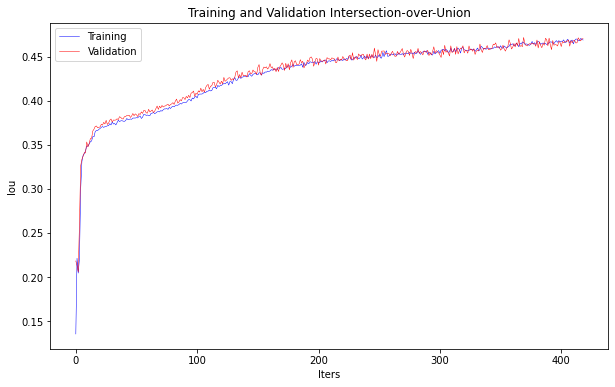

In [12]:
train_val_iou(df['train_iou'], df['val_iou'], len(df['epoch']), save=False)

In [13]:
def train_val_loss(loss_train, loss_val, epochs, save = True, fig_name=''):
    epoch = range(epochs)
    fig, ax = plt.subplots(1,1, figsize = (10,6))   
    ax.plot(epoch, loss_train, color='b', linewidth=0.5, label='Training')
    ax.plot(epoch, loss_val, color='r', linewidth=0.5, label='Validation')

    ax.set_xlabel('Iters')
    ax.set_ylabel('Loss')
    ax.set_title('Training and Validation Loss')
    ax.legend()
    plt.show()
    if save==True:
        fig.savefig(fig_name+'.png', transparent=False, facecolor='white', bbox_inches='tight')

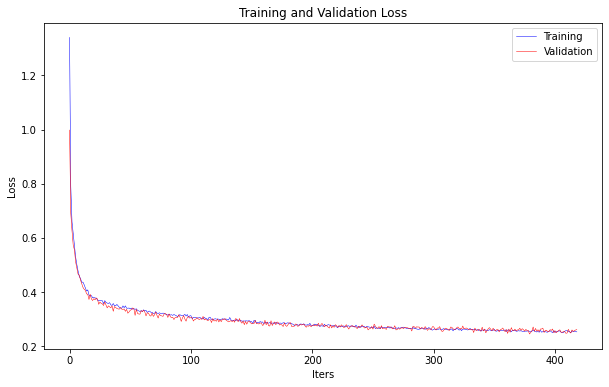

In [14]:
train_val_loss(df['train_loss'], df['val_loss'], len(df['epoch']), save=False)

In [15]:
def train_val_acc(loss_train, loss_val, epochs, save = True, fig_name=''):
    epoch = range(epochs)
    fig, ax = plt.subplots(1,1, figsize = (10,6))   
    ax.plot(epoch, loss_train, color='b', linewidth=0.5, label='Training')
    ax.plot(epoch, loss_val, color='r', linewidth=0.5, label='Validation')

    ax.set_xlabel('Iters')
    ax.set_ylabel('Accuracy')
    ax.set_title('Training and Validation Accuracy')
    ax.legend()
    plt.show()
    if save==True:
        fig.savefig(fig_name+'.png', transparent=False, facecolor='white', bbox_inches='tight')

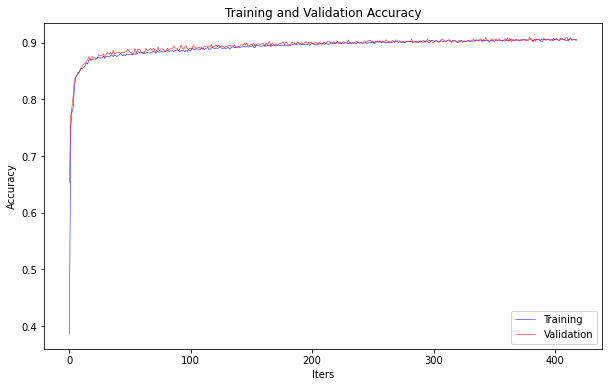

In [26]:
train_val_acc(df['train_acc'], df['val_acc'], len(df['epoch']), save=False)

# Testing

In [12]:
model.load_state_dict(torch.load('weights/best_model_weights.pt'))

<All keys matched successfully>

In [13]:
criterion = nn.CrossEntropyLoss().to(device)  

test_loss, test_acc,test_iou = test(model, test_loader, criterion, device)
print('Testing IoU:',test_iou)
print('Testing Accuracy',test_acc)


10it [00:22,  2.21s/it]

Testing IoU: 0.4715666284348002
Testing Accuracy 0.9093206048011779


In [14]:
from torchmetrics import JaccardIndex
iou = JaccardIndex(task='multiclass', num_classes=4).to(device)

0it [00:00, ?it/s]

tensor(0.4619, device='cuda:0')
torch.Size([32, 4, 320, 320])
[0.9060146002720988, 0.7411528746099116, 0.0059506807578787015, 0.19436948892624378]


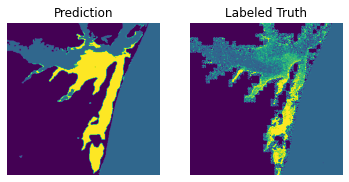

1it [00:00,  1.11it/s]

tensor(0.4621, device='cuda:0')
torch.Size([32, 4, 320, 320])
[0.9247976873390849, 0.7348412636749359, 0.0034418779746699293, 0.18543948323050116]


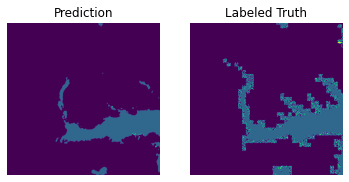

2it [00:01,  1.15it/s]

tensor(0.4768, device='cuda:0')
torch.Size([32, 4, 320, 320])
[0.9287110020295464, 0.7272827470877753, 0.018553459119496855, 0.23254373617534688]


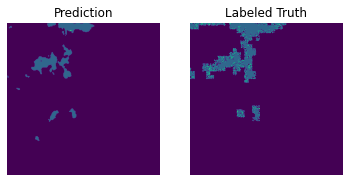

3it [00:02,  1.16it/s]

tensor(0.4757, device='cuda:0')
torch.Size([32, 4, 320, 320])
[0.9388453293342873, 0.7439859476606504, 0.014081060639765093, 0.20579411973365494]


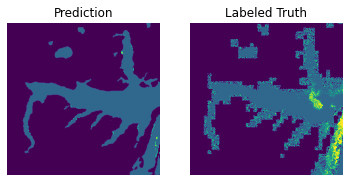

4it [00:03,  1.18it/s]

tensor(0.4645, device='cuda:0')
torch.Size([32, 4, 320, 320])
[0.9279896095791456, 0.7256757922473082, 0.0013082365505272995, 0.2031989266294753]


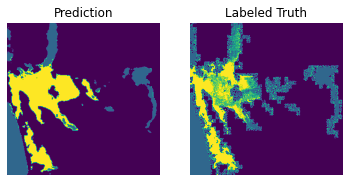

5it [00:04,  1.11it/s]

tensor(0.4699, device='cuda:0')
torch.Size([32, 4, 320, 320])
[0.9271006161219125, 0.7351272919139955, 0.0007280071391667841, 0.21647824164719257]


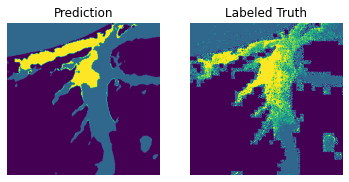

6it [00:05,  1.15it/s]

tensor(0.4582, device='cuda:0')
torch.Size([32, 4, 320, 320])
[0.9112095414870194, 0.7211392578565026, 0.013179530619363196, 0.18714266643782063]


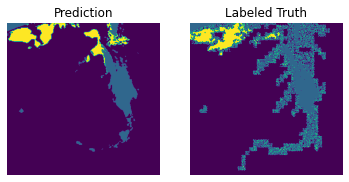

7it [00:06,  1.18it/s]

tensor(0.4786, device='cuda:0')
torch.Size([32, 4, 320, 320])
[0.9233646086709842, 0.7663247454857927, 0.0, 0.224848955522502]


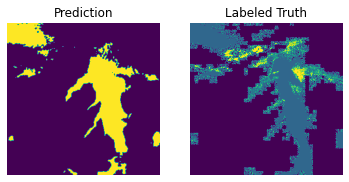

8it [00:06,  1.20it/s]

tensor(0.4670, device='cuda:0')
torch.Size([32, 4, 320, 320])
[0.9229495336877888, 0.7356574787982416, 0.05409739494698259, 0.1554638902369083]


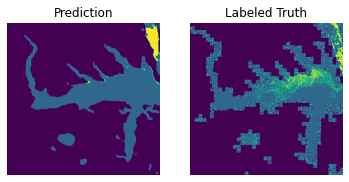

9it [00:07,  1.22it/s]

tensor(0.4534, device='cuda:0')
torch.Size([14, 4, 320, 320])
[0.9355036086158792, 0.6877262140985244, 0.0014506208657305327, 0.18894981872532088]


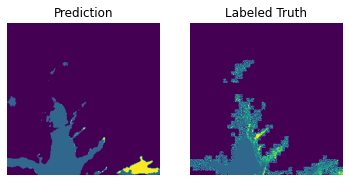

10it [00:08,  1.24it/s]


In [16]:
model.eval()
running_loss = 0
running_acc = 0
test_ious = []
with torch.no_grad():
    for i, batch in tqdm(enumerate(test_loader)):
        x = batch['img'].float().to(device)
        y = batch['fpt'].float().squeeze(dim=1).to(device) #add dim 1

        output = model(x)
        
        print(iou(output, y))
        print(output.shape)
                    
        total_iou, ious = mIOU(y, output, num_classes=4)
        print(ious)
        softmax = nn.Softmax(dim=1)
        preds = torch.argmax(softmax(output),axis=1).to('cpu')
        
        preds1 = np.array(preds[2,:,:])
        
        fig, ax = plt.subplots(1,2)
        ax[0].imshow(preds1)
        ax[0].set_title('Prediction')
        ax[0].axis('off')
        ax[1].imshow(y[2,:,:].to('cpu'))
        ax[1].set_title('Labeled Truth')
        ax[1].axis('off')
        plt.show()
        torch.cuda.empty_cache()


In [ ]:
df = pd.read_csv('history.csv')